# Latent Pretraining Test

Dev notebook for the SSL pretrainer `MaskedLatentPretrainer`. Pretraining masks PCA components independently per modality and reconstructs held-out SC/FC coefficients from whatever visible SC+FC context remains. The objective is representation learning: no downstream-task supervision is used.

At inference, `forward(x)` runs the zero-shot downstream-analog pattern — all FC components masked, all SC components visible — and decodes to FC edge space. This lets us see whether the multimodal reconstruction objective implicitly teaches an SC→FC map without any downstream fine-tuning.

Covariate CLS token is optional via `use_covariates_cls`; when enabled, a per-subject cov-projected CLS is prepended to the token sequence and attended to by all SC/FC tokens (never masked, never reconstructed).

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import main
import models.registry
import models.train.loss
import models.train.lightning_module
import models.eval.evaluator
import models.architectures.latent_attention.latent_attn_masked
import models.architectures.latent_attention.masked_latent_pretrainer

importlib.reload(models.train.loss)
importlib.reload(models.train.lightning_module)
importlib.reload(models.eval.evaluator)
importlib.reload(models.architectures.latent_attention.latent_attn_masked)
importlib.reload(models.architectures.latent_attention.masked_latent_pretrainer)
importlib.reload(models.registry)
importlib.reload(main)

from main import Sim
from models.architectures.utils import get_model_input
from models.registry import build_model

RESULTS_ROOT = Path("results/local_results")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

### Instantiate Sim and pretrainer config

Notes on the config knobs:
- `sc_mask_ratio`, `fc_mask_ratio` are independent Bernoulli rates per modality.
- `zscore_pca_scores=True` is the recommended default; it puts the scalar slot on unit scale across components and makes the per-modality latent loss weights uniform.
- `loss_type` must be `latent_mse` or `latent_weighted_mse`; other loss types will not exercise the SSL reconstruction path.
- `use_covariates_cls=False` here for the clean SC+FC reconstruction baseline. Flip to `True` to add the cov-projected CLS token.

In [2]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "token_embedding_dim": 32,
        "attn_dim": 32,
        "value_dim": 32,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "softmax",
        "readout_type": "linear",
        "zscore_pca_scores": True,
        "sc_mask_ratio": 0.1,
        "fc_mask_ratio": 0.1,
        "min_masked_components_per_modality": 1,
        "use_covariates_cls": False,
        "loss_weighting": "per_modality_mean",
        "reg": 1e-6,
    },
    "trainer": {
        "max_epochs": 200,
        "batch_size": 128,
        "lr": 1.0e-3,
        "loss_type": "latent_weighted_mse",
    },
}

sim = Sim(
    model_name="MaskedLatentPretrainer",
    config_overrides=pretrain_config,
    source="SC",
    target="FC",
    parcellation="Glasser",
    shuffle_seed=0,
    data_load_mode="precomputed",
)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Train

`run_single(mode="dev")` runs standard PL training, plots training history at the end, then runs full evaluation. The evaluation uses `forward(x)`, which executes the zero-shot downstream pattern (all FC masked, all SC visible) and decodes to FC edge space. So the reported edge-space metrics answer: *what FC can this pretrainer generate from SC alone, without fine-tuning?*

#### Test linear model

MaskedLatentPretrainer init | src=SC tgt=FC | k=128 token_dim=33 | attn_dim=32 value_dim=32 num_heads=1 | transformer_layers=0 readout=linear | token_emb_type=learned visible_only_attn=True | zscore=True sc_p=0.15 fc_p=0.15 | use_cov_cls=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                   | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model | MaskedLatentPretrainer | 11.4 K | train | 0    
-----------------------------------------------------------------
11.4 K    Trainable params
0         Non-trainable params
11.4 K    Total params
0.046     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.



Training complete!


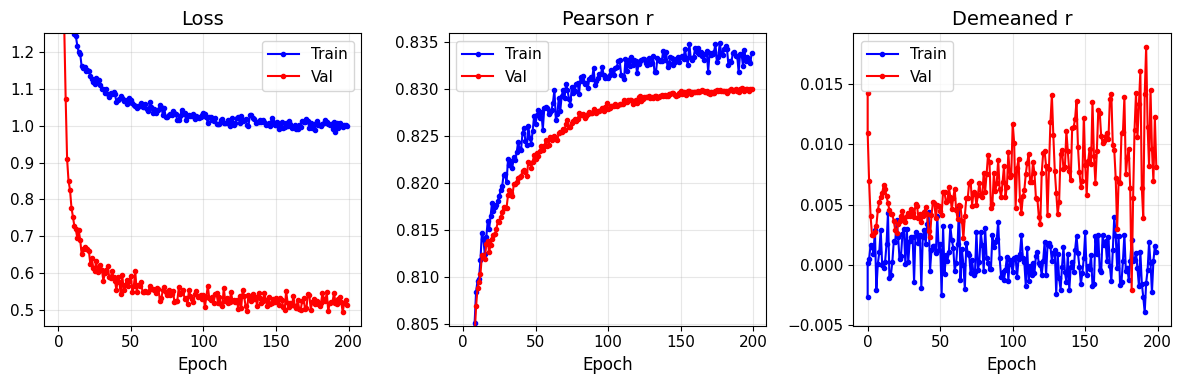

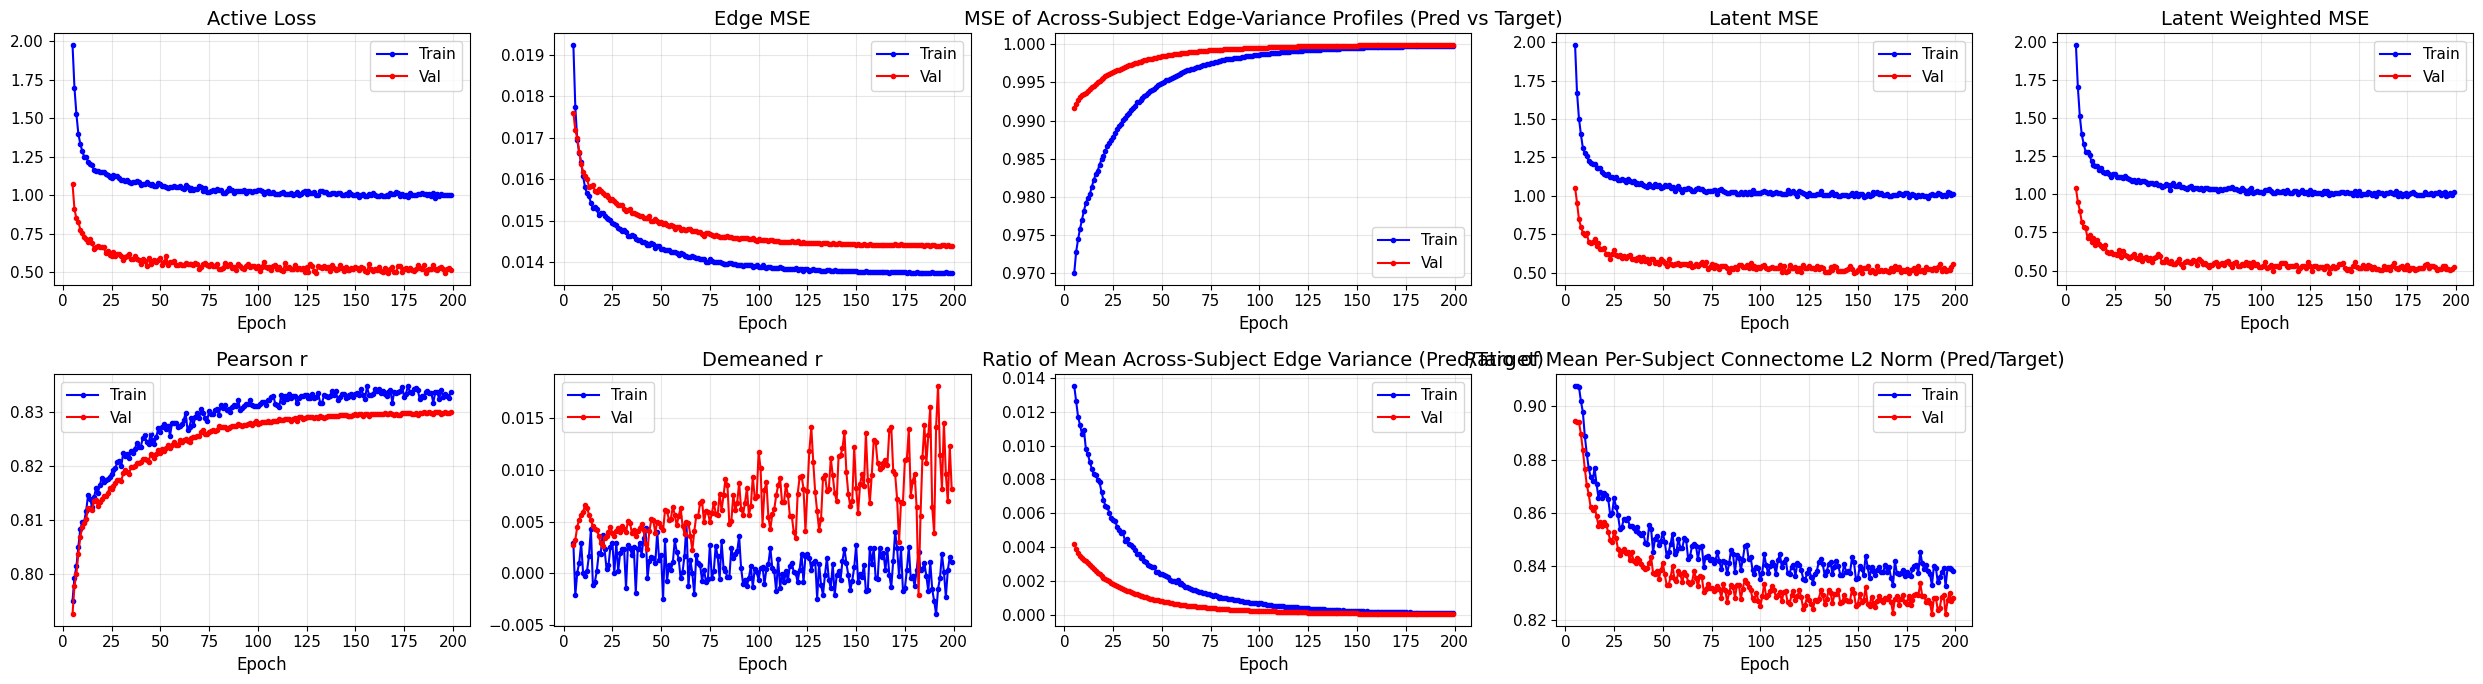

In [10]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "zscore_pca_scores": True,
        "token_embedding_type": "learned", # learned_cov_init     
        #"prior_qk_init_scale": 0.5,
        #"reg": 0.5,
        "visible_only_attention": True,
        "token_embedding_dim": 32,
        "attn_dim": 32,
        "value_dim": 32,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "linear",
        "sc_mask_ratio": 0.15,
        "fc_mask_ratio": 0.15,
        "min_masked_components_per_modality": 1,
        "use_covariates_cls": False,
        # "loss_weighting": "per_modality_mean",
        "reg": 0, #1e-7,
    },
    "trainer": {
        "max_epochs":200,
        "lr": 5.0e-4,
        "loss_type": "latent_mse",
        #"loss_terms": ["latent_mse"],
    },
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=pretrain_config,
    run_eval=False,
)

pretrainer = run_out["model"]
pretrainer.eval()
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)

In [4]:
import importlib
import models.eval.pretrain_eval
importlib.reload(models.eval.pretrain_eval)
from models.eval.pretrain_eval import per_component_recon_sweep, plot_per_component_recon
from models.eval.pretrain_eval import diagnose_split

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"   
pretrainer.to(device)
diag_train = diagnose_split(pretrainer, sim.train_loader, device, "fc", "train")                                                        
diag_val   = diagnose_split(pretrainer, sim.val_loader,   device, "fc", "val")  
# make this much more readable showing mean first +/- std dev instead of var as you've formatted
# then drop the R^2 metrics as they are confusing

[diagnose train fc] n=683 k=128
  target: var mean=1.0000 med=1.0000 min=1.0000 max=1.0000 | mean mean=0.0000 med=0.0000 min=-0.0000 max=0.0000
  pred  : var mean=0.0000 med=0.0000 min=0.0000 max=0.0000 | mean mean=-0.0125 med=-0.0130 min=-0.0330 max=0.0080
  MSE   : mean=1.0002 med=1.0002 min=1.0000 max=1.0011
  Pearson r per comp: mean=0.0080 med=0.0053 min=-0.0880 max=0.1702
  R² naive (1-MSE)      : mean=-0.0002 med=-0.0002 min=-0.0011 max=0.0000
  R² honest (1-MSE/Var) : mean=-0.0002 med=-0.0002 min=-0.0011 max=0.0000
[diagnose val fc] n=79 k=128
  target: var mean=0.5359 med=0.4839 min=0.2255 max=1.1607 | mean mean=0.0056 med=-0.0017 min=-0.1843 max=0.2255
  pred  : var mean=0.0000 med=0.0000 min=0.0000 max=0.0000 | mean mean=-0.0125 med=-0.0130 min=-0.0329 max=0.0079
  MSE   : mean=0.5449 med=0.4949 min=0.2404 max=1.1694
  Pearson r per comp: mean=-0.0033 med=-0.0059 min=-0.3651 max=0.3117
  R² naive (1-MSE)      : mean=0.4551 med=0.5051 min=-0.1694 max=0.7596
  R² honest (1-MSE

In [ ]:
# revisit why MSE converges to 0.5 specifically 

In [13]:
# pretrainer = run_out["model"].eval()                                                                                                                                                                                         
# device = "cuda" if torch.cuda.is_available() else "cpu"                      

# # this plot is okay as it shows the per component recon error
# # drop r^2 from this plot entirely 
# results = {                                                                  
#     "FC (train)": per_component_recon_sweep(pretrainer, sim.train_loader,
# device, "fc"),                                                               
#     "FC (val)":   per_component_recon_sweep(pretrainer, sim.val_loader,
# device, "fc"),                                                         
# }                                
                                            
# plot_per_component_recon(results)

#### Test non-linear model

MaskedLatentPretrainer init | src=SC tgt=FC | k=128 token_dim=33 | attn_dim=32 value_dim=32 num_heads=1 | transformer_layers=2 readout=mlp | token_emb_type=learned visible_only_attn=True | zscore=True sc_p=0.15 fc_p=0.15 | use_cov_cls=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                   | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model | MaskedLatentPretrainer | 35.9 K | train | 0    
-----------------------------------------------------------------
35.9 K    Trainable params
0         Non-trainable params
35.9 K    Total params
0.143     Total estimated model params size (MB)
45        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


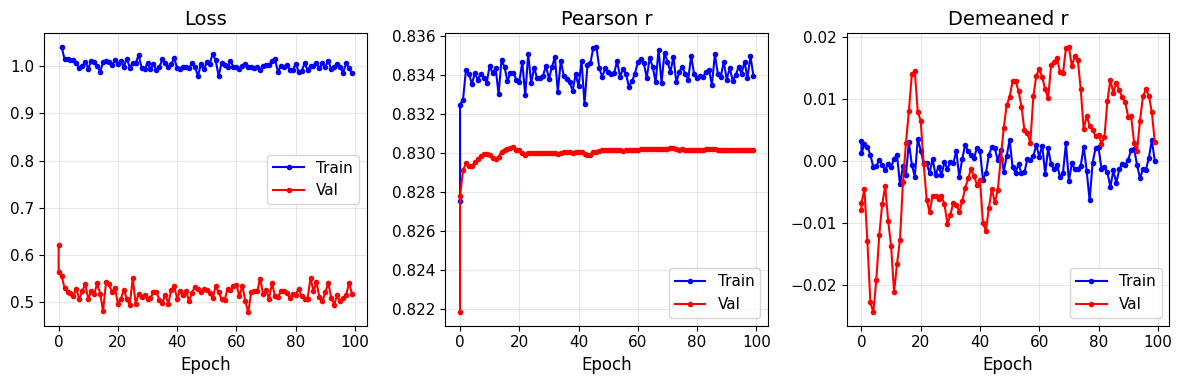

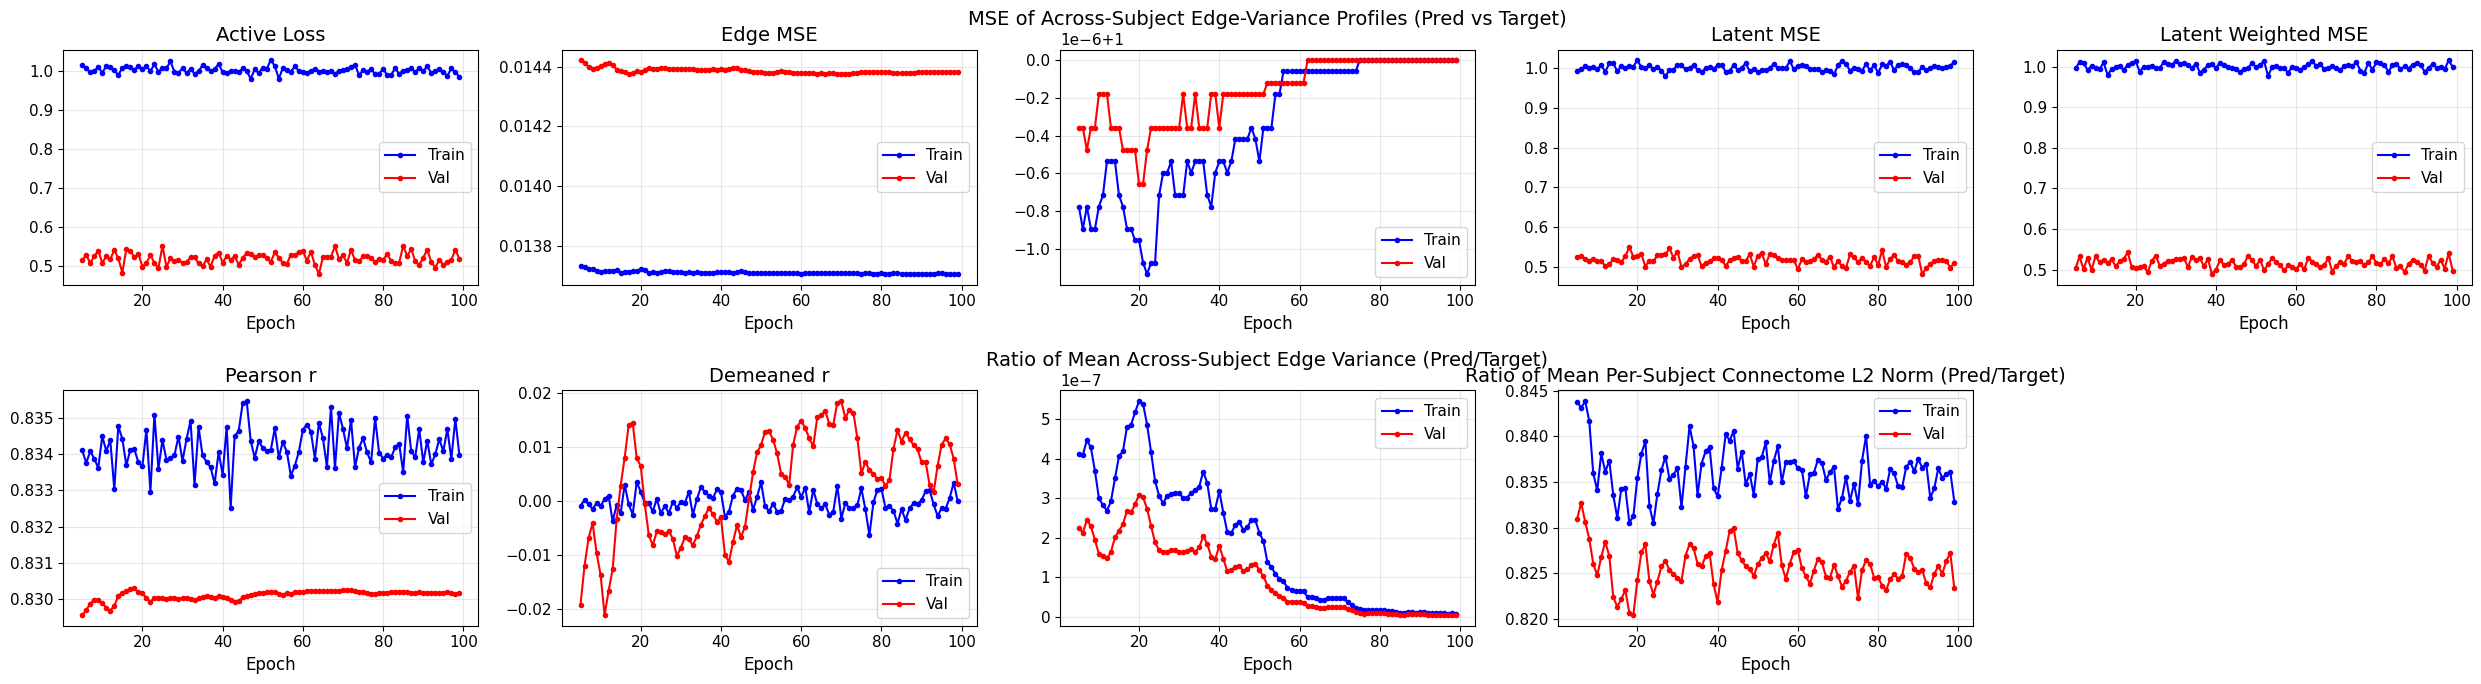

In [11]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "zscore_pca_scores": True,
        "token_embedding_dim": 32,
        "attn_dim": 32,
        "value_dim": 32,
        "transformer_layers": 2,
        "num_heads": 1,
        "attention_activation": "softmax",
        "readout_type": "mlp",
        # "readout_hidden_dim": [32, 16],
        "sc_mask_ratio": 0.15,
        "fc_mask_ratio": 0.15,
        "min_masked_components_per_modality": 1,
        "use_covariates_cls": False,
        # "loss_weighting": "per_modality_mean",
        "reg": 0, #1e-7,
    },
    "trainer": {
        "max_epochs": 100,
        "lr": 1.0e-3,
        "loss_type": "latent_mse",
    },
}


run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=pretrain_config,
    run_eval=False,
)

pretrainer = run_out["model"]
pretrainer.eval()
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)

[sweep fc] device=cuda n=683 k=128 forwards=128 concat=0.01s
[sweep fc] j=16/128 elapsed=19.88s
[sweep fc] j=32/128 elapsed=39.56s
[sweep fc] j=48/128 elapsed=58.96s
[sweep fc] j=64/128 elapsed=78.32s
[sweep fc] j=80/128 elapsed=97.76s
[sweep fc] j=96/128 elapsed=117.23s
[sweep fc] j=112/128 elapsed=136.72s
[sweep fc] j=128/128 elapsed=156.16s
[sweep fc] done: n=683 total=156.17s fwd=156.16s (1220.02 ms/fwd) concat=0.01s
[sweep fc] device=cuda n=79 k=128 forwards=128 concat=0.00s
[sweep fc] j=16/128 elapsed=11.32s
[sweep fc] j=32/128 elapsed=22.42s
[sweep fc] j=48/128 elapsed=33.77s
[sweep fc] j=64/128 elapsed=45.03s
[sweep fc] j=80/128 elapsed=55.95s
[sweep fc] j=96/128 elapsed=66.97s
[sweep fc] j=112/128 elapsed=78.01s
[sweep fc] j=128/128 elapsed=89.41s
[sweep fc] done: n=79 total=89.41s fwd=89.41s (698.50 ms/fwd) concat=0.00s


(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'Per-component reconstruction (mask 1 component, all else visible)'}, ylabel='masked MSE'>,
        <Axes: xlabel='component index', ylabel='R² = 1 - MSE'>],
       dtype=object))

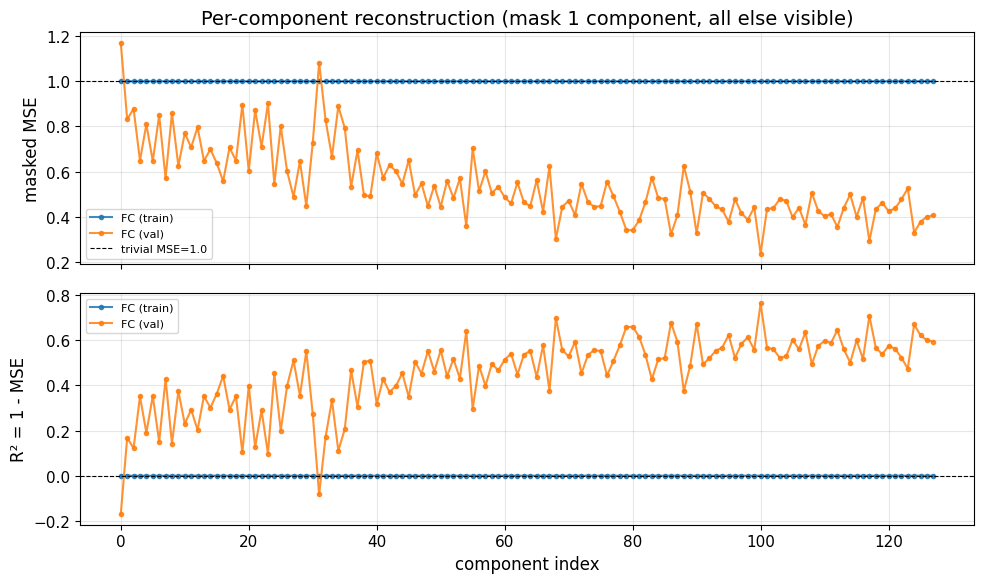

In [8]:
pretrainer = run_out["model"].eval()                                                                                                                 
                                                                            
# device = next(pretrainer.parameters()).device             
device = "cuda" if torch.cuda.is_available() else "cpu"                      
results = {                                                                  
    "FC (train)": per_component_recon_sweep(pretrainer, sim.train_loader,
device, "fc"),                                                               
    "FC (val)":   per_component_recon_sweep(pretrainer, sim.val_loader,
device, "fc"),                                                         
}                                
                                            
plot_per_component_recon(results)

Large model to encourage overfitting

MaskedLatentPretrainer init | src=SC tgt=FC | k=128 token_dim=65 | attn_dim=64 value_dim=64 num_heads=4 | transformer_layers=2 readout=mlp | token_emb_type=learned visible_only_attn=True | var_match_w=0.0 | zscore=True sc_p=0.01 fc_p=1.0 | use_cov_cls=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                   | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model | MaskedLatentPretrainer | 152 K  | train | 0    
-----------------------------------------------------------------
152 K     Trainable params
0         Non-trainable params
152 K     Total params
0.608     Total estimated model params size (MB)
49        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-p


Training complete!


Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line

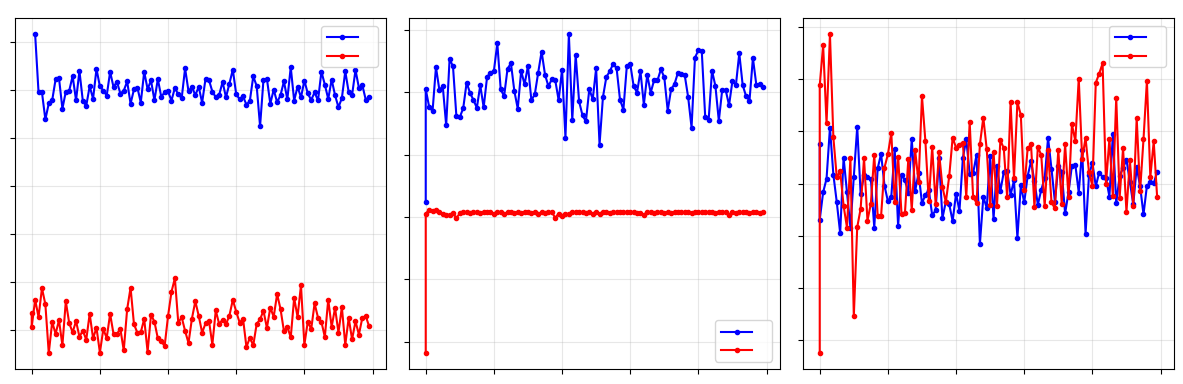

Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 219, in get_text_width_height_descent
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line

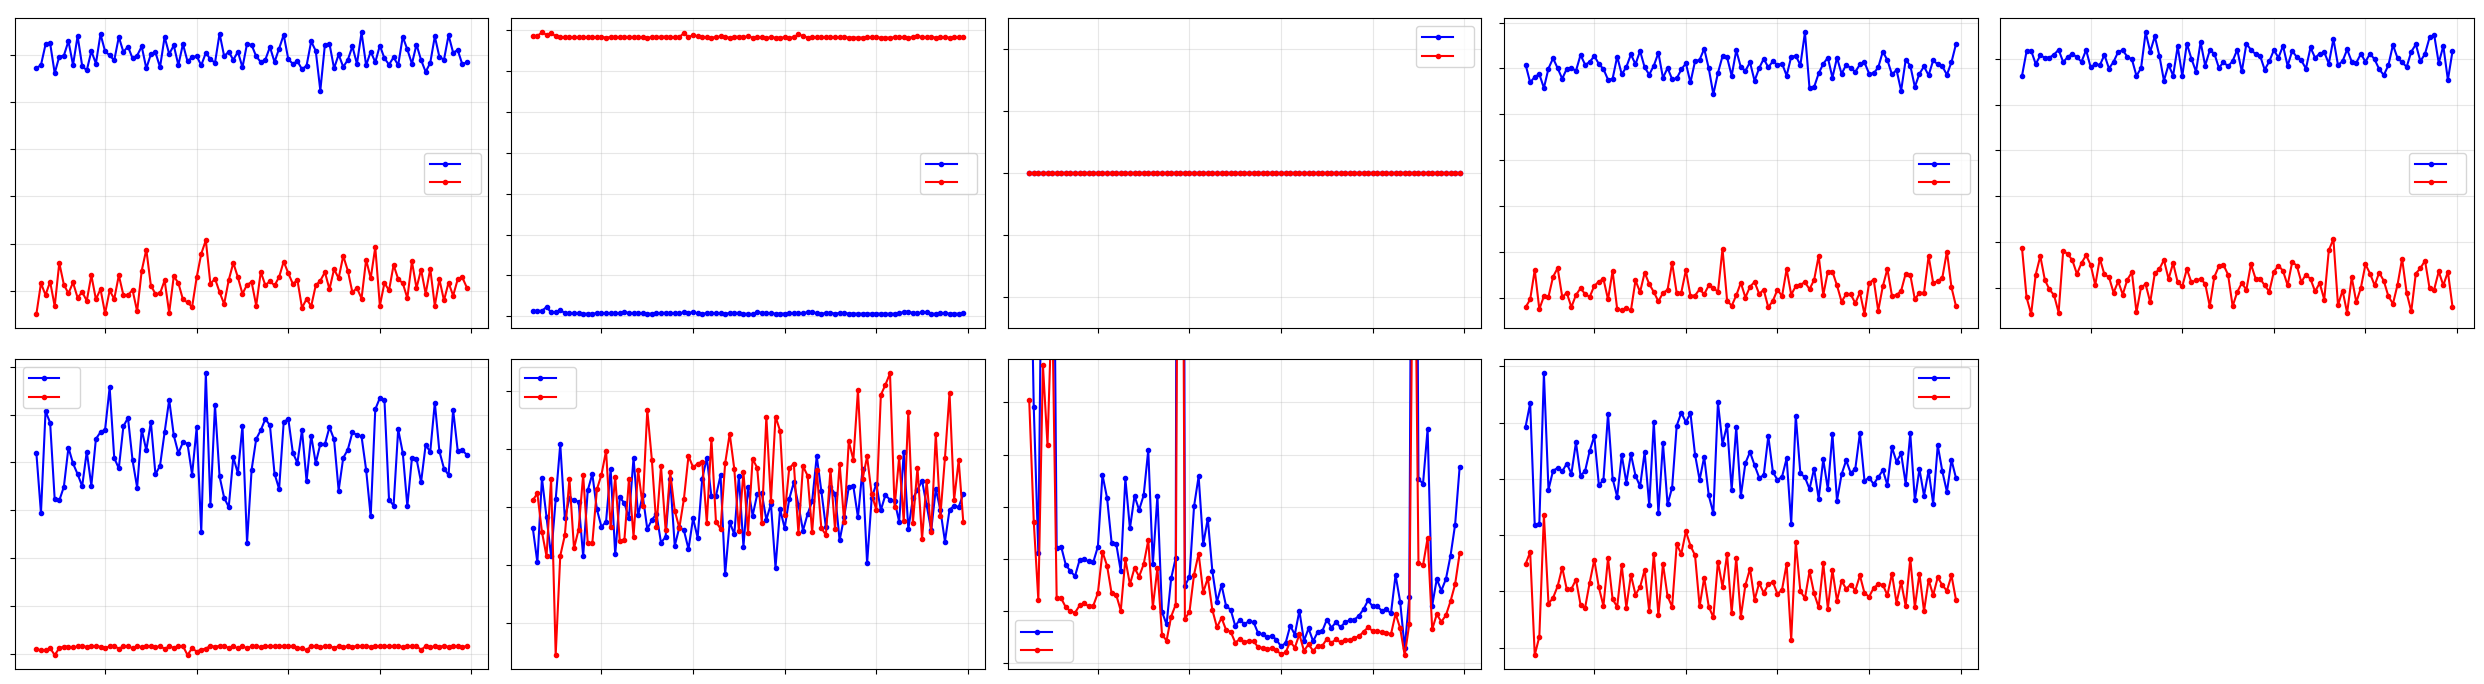

In [10]:
overfit_config = {
    "model": {
        "n_components_pca": 128,
        "zscore_pca_scores": True,
        "token_embedding_dim": 64,
        "attn_dim": 64,
        "value_dim": 64,
        "transformer_layers": 2,
        "num_heads": 4,
        "attention_activation": "softmax",
        "readout_type": "mlp",
        "readout_hidden_dim": [128, 64],
        "token_embedding_type": "learned",  # drop learned_cov_init — need transformer_layers=0 for that
        "visible_only_attention": True,
        "sc_mask_ratio": 0.01,
        "fc_mask_ratio": 1.0,
        "min_masked_components_per_modality": 1,
        "use_covariates_cls": False,
        "reg": 0.0,  # no regularization, we WANT memorization
    },
    "trainer": {
        "max_epochs": 100,
        "lr": 1e-2,
        "loss_type": "latent_mse",
    },
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=overfit_config,
    run_eval=False
)

pretrainer = run_out["model"].eval()
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)


### Inspect per-modality reconstruction under a random joint mask

In [9]:
val_batch = next(iter(sim.val_loader))

out = pretrainer.reconstruct(val_batch)
print("c_source      :", tuple(out["c_source"].shape))
print("c_target      :", tuple(out["c_target"].shape))
print("c_source_hat  :", tuple(out["c_source_hat"].shape))
print("c_target_hat  :", tuple(out["c_target_hat"].shape))
print("sc_mask frac  :", float(out["sc_mask"].float().mean()))
print("fc_mask frac  :", float(out["fc_mask"].float().mean()))

c_source      : (79, 128)
c_target      : (79, 128)
c_source_hat  : (79, 128)
c_target_hat  : (79, 128)
sc_mask frac  : 0.09770569950342178
fc_mask frac  : 0.0957278460264206


### Per-component reconstruction error (masked positions only)

For each PCA component, average squared reconstruction error across subjects for which that component was masked. Useful for spotting which components the model struggles with; trailing components are harder to predict from context because they carry less variance and less shared structure across modalities.

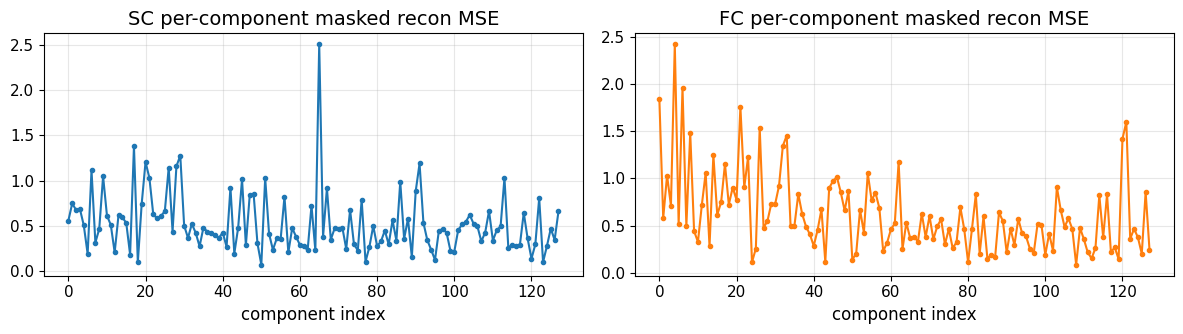

In [10]:
sc_err, fc_err = pretrainer.per_component_reconstruction_error(val_batch)
sc_err = sc_err.detach().cpu().numpy()
fc_err = fc_err.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(sc_err, "-o", ms=3)
axes[0].set_title("SC per-component masked recon MSE")
axes[0].set_xlabel("component index")
axes[0].grid(alpha=0.3)
axes[1].plot(fc_err, "-o", ms=3, color="tab:orange")
axes[1].set_title("FC per-component masked recon MSE")
axes[1].set_xlabel("component index")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Zero-shot FC-from-SC eval (matches downstream inference pattern)

`forward(x)` runs the all-FC-masked / all-SC-visible forward pass and returns decoded FC edges. We compare true vs predicted on the val batch to check whether the pretrainer's kernel already does useful SC→FC without any fine-tuning.

In [6]:
with torch.no_grad():
    x = get_model_input(val_batch).to(pretrainer.source_mean.device)
    y = val_batch["y"].to(pretrainer.target_mean.device)
    y_pred = pretrainer(x)
    diff = (y_pred - y)
    mse = diff.pow(2).mean().item()
    y_c = y - y.mean(dim=1, keepdim=True)
    y_pred_c = y_pred - y_pred.mean(dim=1, keepdim=True)
    pearson = ((y_c * y_pred_c).sum(dim=1) / (y_c.norm(dim=1) * y_pred_c.norm(dim=1) + 1e-8)).mean().item()

print(f"Zero-shot FC-from-SC | MSE={mse:.4e}  Pearson r={pearson:.4f}")

Zero-shot FC-from-SC | MSE=1.4553e-02  Pearson r=0.8276


### Optionally transfer weights to LatentAttnMasked for fine-tuning

Build a fresh `LatentAttnMasked` whose token/attention shapes match the pretrainer, then copy compatible weights. The returned report lists what was copied and what was skipped (e.g. if downstream `readout_type` changes the FC readout shape).

In [ ]:
downstream_cfg = {
    "n_components_pca": 128,
    "token_embedding_type": "learned",
    "token_embedding_dim": 32,
    "attn_dim": 32,
    "value_dim": 32,
    "transformer_layers": 0,
    "num_heads": 1,
    "attention_activation": "softmax",
    "readout_type": "linear",
    "residual_mode": "attention_only",
    "train_use_visible_fc_context": False,
    "mask_ratio": 1.0,
    "zscore_pca_scores": True,
    "reg": 1e-6,
}
downstream = build_model(sim.base, "LatentAttnMasked", downstream_cfg)
transfer_report = pretrainer.export_to_latent_attn_masked(downstream)
print("Copied:")
for k in transfer_report["copied"]:
    print(f"  + {k}")
print("Skipped:")
for k, reason in transfer_report["skipped"]:
    print(f"  - {k}: {reason}")

## Math Summary

**Setup.** Let $k$ be the number of retained PCA components per modality. For each subject, compute source and target PCA score vectors

$$
c_s = (X - \mu_s)\, U_s \in \mathbb{R}^k, \qquad c_t = (Y - \mu_t)\, U_t \in \mathbb{R}^k,
$$

where $U_s, U_t$ are the truncated PCA loadings and $\mu_s, \mu_t$ are the training means. With `zscore_pca_scores=True`, each component is standardized to unit variance using the training-set per-component std.

**Tokens.** Per subject, the pretrainer builds a sequence of $2k$ (or $2k+1$ with a CLS token) tokens:

$$
\text{SC}_i = \big[\, s_i \;\big\|\; e^{(\mathrm{sc})}_i \,\big], \qquad
\text{FC}_j = \big[\, f_j \;\big\|\; e^{(\mathrm{fc})}_j \,\big],
$$

with the scalar slot

$$
s_i = \begin{cases} c_{s,i} & \text{if } m^{(\mathrm{sc})}_i = 0 \\ \text{sc\_mask\_value} & \text{if } m^{(\mathrm{sc})}_i = 1 \end{cases}
\qquad
f_j = \begin{cases} c_{t,j} & \text{if } m^{(\mathrm{fc})}_j = 0 \\ \text{fc\_mask\_value} & \text{if } m^{(\mathrm{fc})}_j = 1 \end{cases}
$$

Masks are sampled independently per modality: $m^{(\mathrm{sc})}_i \sim \text{Bernoulli}(p_\mathrm{sc})$, $m^{(\mathrm{fc})}_j \sim \text{Bernoulli}(p_\mathrm{fc})$, with a floor of `min_masked_components_per_modality` per row. Component embeddings $e^{(\mathrm{sc})}$ and $e^{(\mathrm{fc})}$ are separate learnable tables in $\mathbb{R}^{k\times d_\mathrm{emb}}$ — this decoupling avoids baking in a symmetric SC↔FC identification.

**Optional CLS token.** If `use_covariates_cls=True`, prepend

$$
\text{CLS} = g_\theta(\mathrm{cov}) \in \mathbb{R}^{1 + d_\mathrm{emb}},
$$

where $g_\theta$ is a learned linear (or 1-hidden-layer MLP) projection from the per-subject covariate vector. The CLS token is never masked and has no reconstruction target.

**Attention.** The full token sequence $T \in \mathbb{R}^{N\times (1+d_\mathrm{emb})}$ (with $N = 2k$ or $2k+1$) goes through either a raw single-attention block or a stack of transformer blocks, producing output $Z \in \mathbb{R}^{N\times d_\mathrm{out}}$. For the raw path,

$$
Q = T W_Q,\quad K = T W_K,\quad V = T W_V,\qquad Z = \sigma\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V,
$$

with $\sigma$ either softmax (row-normalized) or identity.

**Readouts.** Two per-modality heads map attention outputs to reconstructed PCA coefficients:

$$
\hat c_{s,i} = h_{\mathrm{sc}}(Z^{(\mathrm{sc})}_i),\qquad
\hat c_{t,j} = h_{\mathrm{fc}}(Z^{(\mathrm{fc})}_j),
$$

where $Z^{(\mathrm{sc})}, Z^{(\mathrm{fc})}$ are the SC/FC slices of $Z$ (excluding the CLS position if present). Heads are either linear or a 1-hidden MLP.

**Loss.** Reconstruction MSE is averaged over masked positions only, per modality, then combined:

$$
\mathcal{L}_{\mathrm{pre}}
= \tfrac{1}{2}\Bigg(
\frac{\sum_i w^{(\mathrm{sc})}_i\, m^{(\mathrm{sc})}_i (\hat c_{s,i} - c_{s,i})^2}{\sum_i m^{(\mathrm{sc})}_i}
+
\frac{\sum_j w^{(\mathrm{fc})}_j\, m^{(\mathrm{fc})}_j (\hat c_{t,j} - c_{t,j})^2}{\sum_j m^{(\mathrm{fc})}_j}
\Bigg) + \lambda\, \mathcal{R}(\Theta).
$$

Weights $w^{(\cdot)}$ are all-ones when `loss_type=latent_mse` or when `zscore_pca_scores=True`, and variance-proportional when `loss_type=latent_weighted_mse` without z-scoring. $\mathcal{R}$ is the L2 penalty over embeddings, attention kernels, readout heads, and (if active) the cov projector.

**Zero-shot inference.** `forward(x)` sets $m^{(\mathrm{sc})} = 0$ (all SC visible) and $m^{(\mathrm{fc})} = 1$ (all FC masked), runs attention, applies the FC head, and decodes:

$$
\hat Y = \hat c_t\, U_t^\top + \mu_t,
$$

with an inverse-standardization step $\hat c_t \leftarrow \hat c_t\,\sigma_t + \mu_{c_t}$ when z-scoring is on. This is the downstream-task pattern — no FC scalar input, reconstruction must flow purely from SC tokens through the learned attention kernel.

**Why SSL here.** Under a single-direction SC→FC objective, the attention kernel only ever needs to encode "how SC-j influences FC-i". Under joint SC+FC masked reconstruction, the kernel must encode both directions and within-modality structure; the model additionally learns that certain FC components are nearly deterministic from other FC components (within-modality redundancy), which at zero-shot FC generation can serve as a consistency regularizer on the FC predictions. The zero-shot forward measures the component of this learned representation that is usable for the downstream SC→FC task without any explicit fine-tuning.